<img src="./Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº0
#### Patricia González Todd


In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
A = np.sqrt(2)
dc = 0
fs = 2
fase = 0
muestras = 1000
f0 = fs/muestras #delta f que es RESOLUCION ESPECTRAL
bits = 4
# 4 bits => 16 niveles
Vf = 2
q = Vf/(2**bits)
Ps = (A**2)/ 2
Pq = (q**2)/12
kn = 2
Pr = kn * Pq #ESTO DEBERIA SER LA VARIANZA
SNR = Ps/Pr
SNR_db = 10*np.log10(SNR)

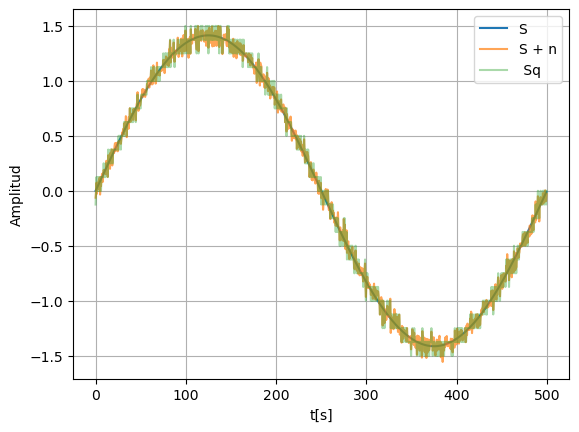

In [20]:
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    # Usamos np.arange(nn) para asegurar exactamente 'nn' muestras
    tt = np.arange(0, nn) * ts 
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

def mi_funcion_sen_ruido(vmax, dc, ff, ph, nn, fs, snr, pr):
    ts = 1/fs
    tt = np.arange(0, nn) * ts
    desvio = np.sqrt(pr)
    r = np.random.normal(0, desvio, len(tt)) # lo del medio es el desvio estandar
    #verifico el valor de la varianza de r a ver si calcule bien
   # print(f"Potencia de ruido (pr): {pr}") # esto es la potencia de ruido
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    xx1 = xx + r
    return tt, xx1
    
# Llamadas a las funciones
tt, S = mi_funcion_sen(A, dc, f0, fase, muestras, fs)
ttn, Sn = mi_funcion_sen_ruido(A, dc, f0, fase, muestras, fs, SNR_db, Pr)
n = Sn-S #deberia ser gaussiana

#Cuantizacion
Sq = q* np.round(Sn/q)

#Error de cuantizacion
Eq = np.abs (Sq - Sn)

# Gráfico senos
plt.plot(tt, S, label="S")
plt.plot(ttn, Sn, label="S + n", alpha=0.7)
plt.plot(ttn, Sq, label = " Sq", alpha=0.4)
plt.xlabel("t[s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.show()

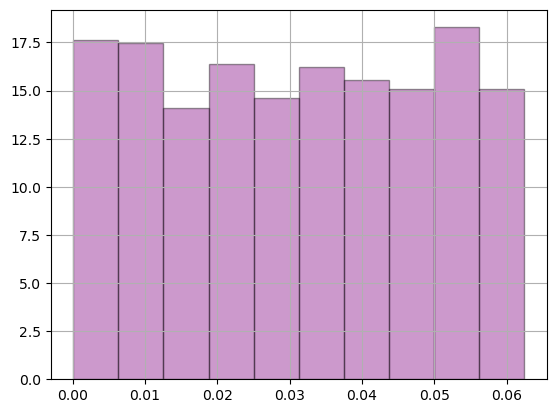

In [21]:
#%% Hitograma de  error de cuantizacion
plt.hist(Eq, bins=10, density= 'true', color='purple', alpha=0.4,
         edgecolor='black')
plt.grid(True)
plt.show()

Text(0, 0.5, 'Amplitud')

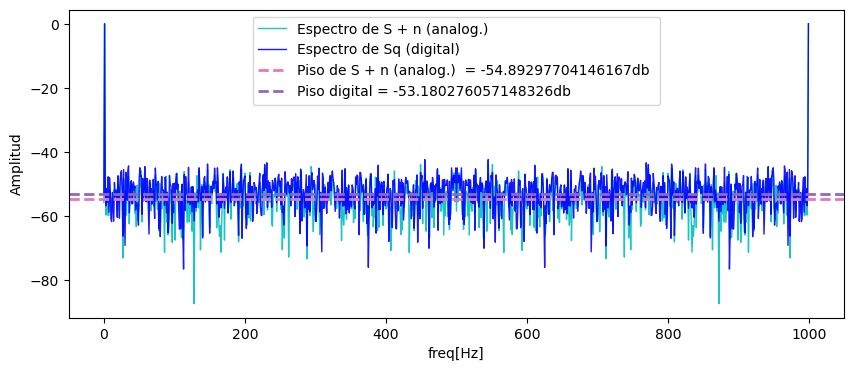

In [26]:
#%% Paso al dominio de espectro:
#Sr
e_Sr = np.fft.fft(Sn)/(muestras/A) 
mod_e_Sr = np.abs((e_Sr))
#Sq
e_Sq = np.fft.fft(Sq)/(muestras/A) 
mod_e_Sq = np.abs((e_Sq))

# paso a db
mod_e_Sr_db = 20*np.log10(mod_e_Sr) #db
mod_e_Sq_db = 20*np.log10(mod_e_Sq) #db

#pisos
piso_analog = np.mean(mod_e_Sr_db) # e_sr es el vector de la FFT/N
piso_digital = np.mean(mod_e_Sq_db) # e_sq es el vector de la FFT/N del error

#intento sumar para ver solo el snr en esa distancia
#mod_e_sr_db = 10*np.log10(mod_e_sr)+(10*np.log10(fs/2)) #db

espectro = np.fft.fftfreq(muestras,1/fs)
ffreq = np.arange(0, muestras) 

# Gráfico SOLO DEL DELTA
plt.figure(figsize=(10, 4))
plt.plot(ffreq, mod_e_Sr_db,'c', label= "Espectro de S + n (analog.)", linewidth=1, alpha = 0.9)
plt.plot(ffreq, mod_e_Sq_db,'b', label= "Espectro de Sq (digital)", linewidth=1, alpha = 0.9)
plt.axhline(piso_analog ,color = 'C6',label = f"Piso de S + n (analog.)  = {piso_analog}db ",
            linestyle='--', linewidth=2)
plt.axhline(piso_digital ,color = 'C14',label = f"Piso digital = {piso_digital}db",
            linestyle='--', linewidth=2)
plt.legend()
plt.xlabel("freq[Hz]")
plt.ylabel("Amplitud")